In [97]:
from word_image import *
from word_shape_analysis import *
from pathlib import Path

In [98]:
from PIL import Image, ImageDraw, ImageFont
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
shape_files = list()
for word in ['hello', 'my', 'name', 'is', 'Aaron']:
    img = create_word_image(word, font_path='ARIAL.TTF')
    gray_shade=128
    new_img, bin_img = clean_image(img)
    contains_lower, contains_upper, contains_capital, contains_regular = find_letter_types(word)
    shape_image = convert_to_shape(bin_img.copy(), gray_shade, contains_lower, contains_upper, contains_capital, contains_regular)
    shape_files.append(shape_image)

In [78]:
img = create_word_image(words='ridiculous', font_path='ARIAL.TTF')
new_img, bin_img = clean_image(img)
low, upp, cap, reg = find_letter_types('ridiculous')
shape = convert_to_shape(bin_img, 128, low, upp, cap, reg)

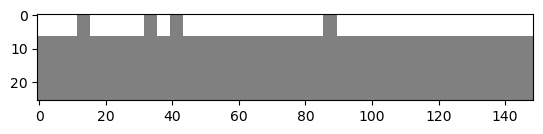

In [79]:
plt.imshow(shape, cmap='gray')

In [156]:
# Finding the best method
image_a = list()
image_b = list()
similarity = list()
methods = list()

data_dict = dict()

In [157]:
words = ['Hello', 'Mello', 'Trickster', 'Pleasant', 'Unbelievable']

for word in words:
    data_dict[word] = get_shape_image(word)

In [158]:
shape = cv2.cvtColor(input_image.astype('uint8'), cv2.COLOR_BGR2GRAY)
# End Aaron's code
_, binary = cv2.threshold(shape, 225, 255, cv2.THRESH_BINARY_INV)
contours, hierarchy = cv2.findContours(binary,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

image = cv2.drawContours(shape, contours, -1, (0, 255, 0), 2)

contours[0]

array([[[ 0,  0]],

       [[ 0, 25]],

       [[77, 25]],

       [[77,  0]]], dtype=int32)

In [159]:
# Double loop through every word image
for filea, imagea in data_dict.items():
    for fileb, imageb in data_dict.items():
        for method in [1,2,3]:
            image_a.append(filea)
            image_b.append(fileb)
            score = cv2.matchShapes(get_contours(imagea),
                                    get_contours(imageb),
                                    method,0)
            similarity.append(score)
            methods.append(method)

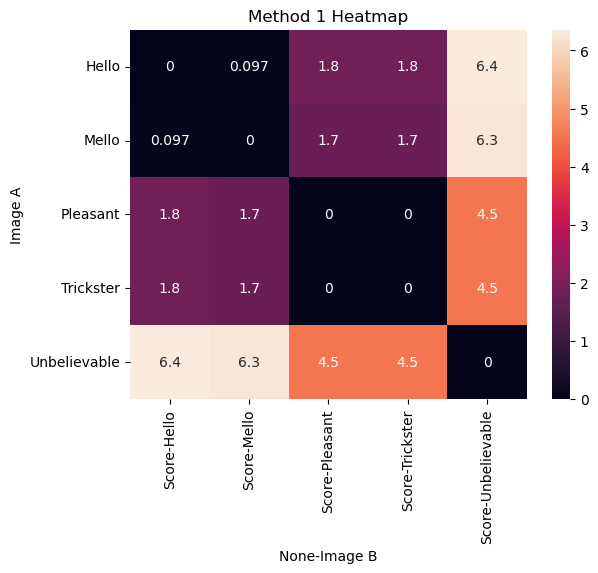

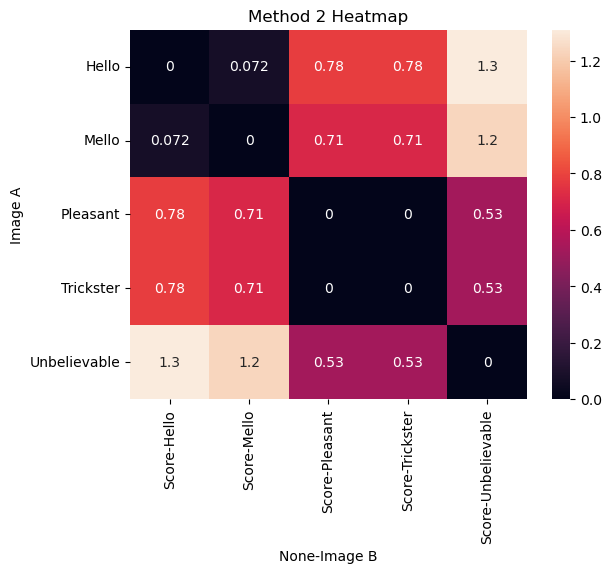

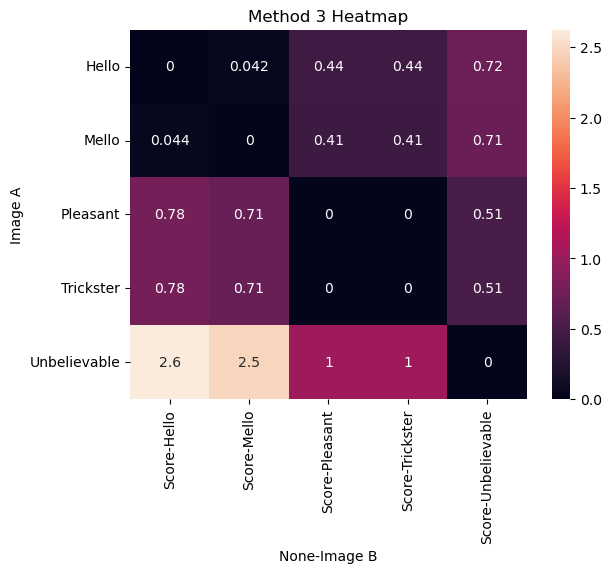

In [173]:
wsh_df = pd.DataFrame({'Image A':image_a,
                        'Image B':image_b,
                        'Score':similarity,
                        'Method':methods})

# Analyzing the methods
wsh_df = wsh_df.sort_values(by=['Method','Score'], ascending=[True, True])

for i in wsh_df['Method'].unique():
    temp_df = wsh_df.loc[wsh_df['Method']==i]
    pivot_df = temp_df.pivot(index='Image A', columns='Image B')[['Score']]
    sns.heatmap(pivot_df, annot=True).set_title(f'Method {i} Heatmap')
    plt.show()
    


In [169]:
wsh_df[wsh_df['Method']==3]

,Image A,Image B,Score,Method
2,Hello,Hello,0.000000,3
20,Mello,Mello,0.000000,3
38,Trickster,Trickster,0.000000,3
41,Trickster,Pleasant,0.000000,3
53,Pleasant,Trickster,0.000000,3
56,Pleasant,Pleasant,0.000000,3
74,Unbelievable,Unbelievable,0.000000,3
5,Hello,Mello,0.042090,3
17,Mello,Hello,0.043940,3
23,Mello,Trickster,0.414305,3
